# Лабораторна робота №2
## Інтелектуальні агенти

Мережевий контролер будує маршрут у зваженому графі з обмеженою локальною видимістю.

## Мета роботи

Розробити раціонального агента, який прокладає шлях між вузлом-відправником і вузлом-отримувачем, може повертатися з тупиків та порівнюється з оптимальними алгоритмами пошуку.

In [1]:
import math
import sys
from pathlib import Path
import random
from math import inf

import matplotlib.pyplot as plt
import networkx as nx

lab1_src = Path.cwd().parents[1] / 'lab1' / 'src'
sys.path.insert(0, str(lab1_src))

from lab1 import create_graph, remove_edges, validate_args

In [2]:
class AgentResult:
    def __init__(self, path, total_delay, installed_rules, revoked_rules, log=None):
        self.path = path
        self.total_delay = total_delay
        self.installed_rules = installed_rules
        self.revoked_rules = revoked_rules
        self.log = [] if log is None else log


def address(graph, node):
    return str(graph.nodes[node].get('address', node))


def edge_weight(graph, u, v):
    weight = graph[u][v].get('weight', 1)
    if weight < 0:
        raise ValueError('Усі ваги ребер повинні бути невід’ємними')
    return float(weight)


def greedy_backtracking_agent(graph, start, target):
    if start not in graph or target not in graph:
        raise ValueError('Початковий і кінцевий вузли мають бути в графі')
    if not nx.is_connected(graph):
        raise ValueError('Граф має бути зв’язним')

    visited = {start}
    path = [start]
    log = []
    installed_rules = 0
    revoked_rules = 0

    def search(current):
        nonlocal installed_rules, revoked_rules

        log.append(f'Поточний вузол: {address(graph, current)}')
        if current == target:
            log.append('Досягнуто вузол-отримувач')
            return True

        candidates = sorted(
            (
                (neighbor, edge_weight(graph, current, neighbor))
                for neighbor in graph.neighbors(current)
                if neighbor not in visited
            ),
            key=lambda item: item[1],
        )

        if not candidates:
            log.append(f'Тупик у вузлі {address(graph, current)}')
            return False

        for neighbor, weight in candidates:
            visited.add(neighbor)
            path.append(neighbor)
            installed_rules += 1
            log.append(
                f'Встановлено правило: {address(graph, current)} -> '
                f'{address(graph, neighbor)} (вага {weight:g})'
            )

            if search(neighbor):
                return True

            path.pop()
            revoked_rules += 1
            log.append(
                f'Відкликано правило: {address(graph, current)} -> '
                f'{address(graph, neighbor)}; повернення назад'
            )

        return False

    if not search(start):
        return AgentResult(None, inf, installed_rules, revoked_rules, log)

    total_delay = sum(
        edge_weight(graph, u, v) for u, v in zip(path, path[1:])
    )
    return AgentResult(
        path.copy(), total_delay, installed_rules, revoked_rules, log
    )


def dijkstra_path(graph, start, target):
    return nx.shortest_path(graph, start, target, weight='weight')


def path_delay(graph, path):
    nodes = list(path)
    return sum(edge_weight(graph, u, v) for u, v in zip(nodes, nodes[1:]))


def compare_paths(graph, start, target):
    agent = greedy_backtracking_agent(graph, start, target)
    dijkstra = dijkstra_path(graph, start, target)
    return {
        'agent': agent,
        'dijkstra_path': dijkstra,
        'dijkstra_delay': path_delay(graph, dijkstra),
    }


def draw_path(graph, path=None, title='Маршрут агента'):
    positions = {
        node: (node[1], -node[0])
        for node in graph.nodes
        if isinstance(node, tuple) and len(node) == 2
    }
    highlighted_edges = set()
    if path:
        highlighted_edges = {
            frozenset((u, v)) for u, v in zip(path, path[1:])
        }

    node_colors = [
        'tomato' if path and node in path else 'lightblue'
        for node in graph.nodes
    ]
    edge_colors = [
        'crimson' if frozenset((u, v)) in highlighted_edges else 'gray'
        for u, v in graph.edges
    ]

    positions.update({
        node: (index, 0)
        for index, node in enumerate(graph.nodes)
        if node not in positions
    })
    plt.figure(figsize=(11, 8))
    nx.draw(
        graph, positions,
        labels={node: address(graph, node) for node in graph.nodes},
        node_color=node_colors, edge_color=edge_colors,
        node_size=1600, font_size=8, width=2,
    )
    nx.draw_networkx_edge_labels(
        graph, positions,
        edge_labels=nx.get_edge_attributes(graph, 'weight'),
        font_size=8,
    )
    plt.title(title)
    plt.axis('off')
    plt.show()


def print_result(graph, result):
    if result.path is None:
        print('Шлях не знайдено')
    else:
        print('Шлях агента:')
        print(' -> '.join(address(graph, node) for node in result.path))
        print(f'Кількість вузлів: {len(result.path)}')
        print(f'Сумарна затримка: {result.total_delay:g}')
    print(f'Встановлено правил: {result.installed_rules}')
    print(f'Відкликано правил: {result.revoked_rules}')


def create_graph_for_lab2(nodes_num=25, edges_to_delete=6, min_weight=1, max_weight=10):
    validate_args(nodes_num, edges_to_delete, min_weight, max_weight)
    graph = create_graph(nodes_num, min_weight, max_weight)
    remove_edges(graph, edges_to_delete)
    return graph

## Створення топології з лабораторної роботи №1

In [3]:
random.seed(42)

graph = create_graph_for_lab2(
    nodes_num=25,
    edges_to_delete=6,
    min_weight=1,
    max_weight=10,
)

start = (0, 0)
target = (4, 4)

print(f'Кількість вузлів: {graph.number_of_nodes()}')
print(f'Кількість ребер: {graph.number_of_edges()}')

Кількість вузлів: 25
Кількість ребер: 34


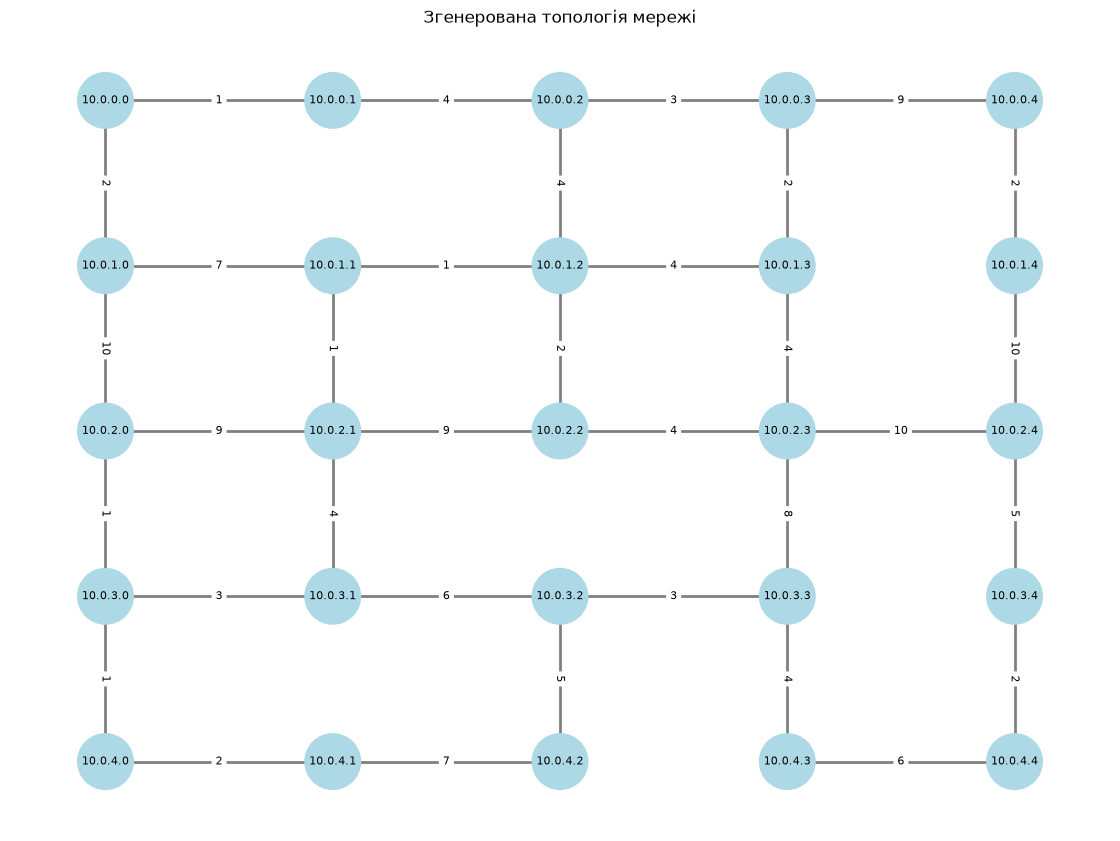

In [4]:
draw_path(graph, title='Згенерована топологія мережі')

## Робота агента

Агент обирає невідвіданого сусіда з найменшою локальною вагою. Якщо всі напрямки приводять у тупик, останнє правило відкликається і агент повертається до попереднього вузла.

Шлях агента:
10.0.0.0 -> 10.0.0.1 -> 10.0.0.2 -> 10.0.0.3 -> 10.0.1.3 -> 10.0.1.2 -> 10.0.1.1 -> 10.0.2.1 -> 10.0.3.1 -> 10.0.3.0 -> 10.0.4.0 -> 10.0.4.1 -> 10.0.4.2 -> 10.0.3.2 -> 10.0.3.3 -> 10.0.4.3 -> 10.0.4.4
Кількість вузлів: 17
Сумарна затримка: 51
Встановлено правил: 18
Відкликано правил: 2


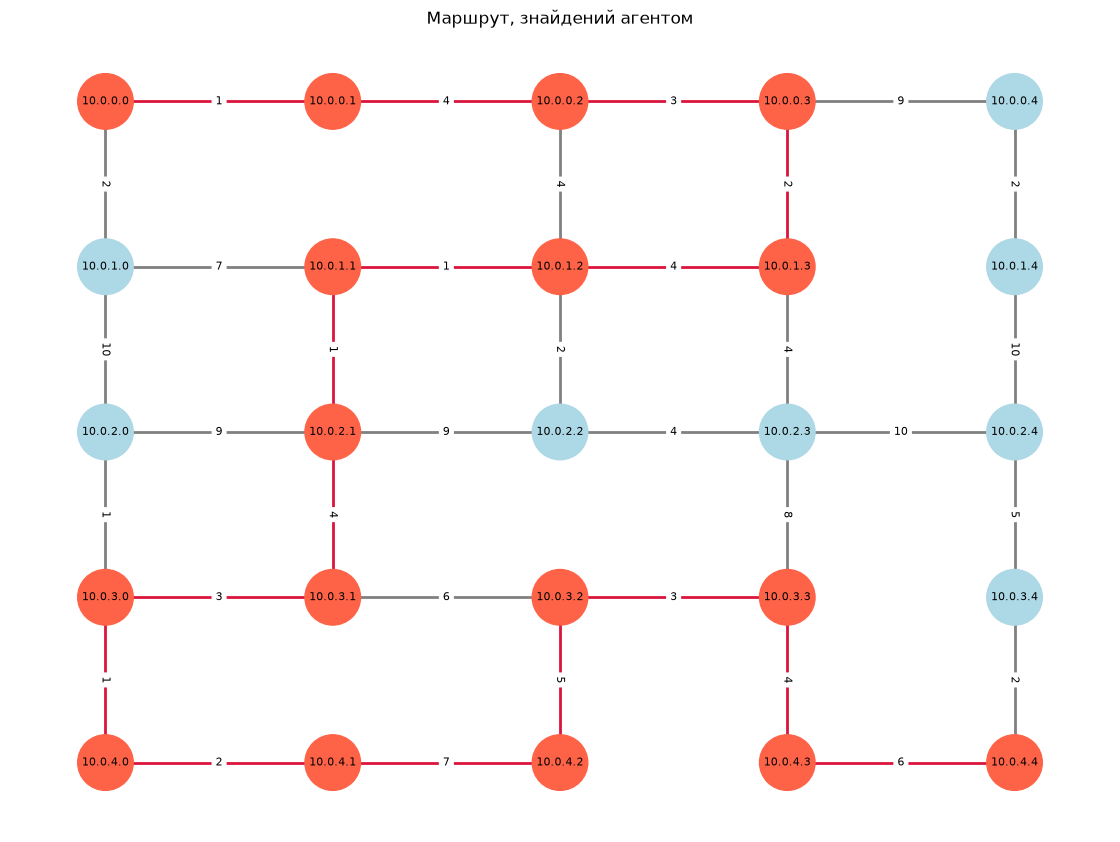

In [5]:
result = greedy_backtracking_agent(graph, start, target)
print_result(graph, result)
draw_path(graph, result.path, title='Маршрут, знайдений агентом')

In [6]:
print('Журнал дій агента:')
for entry in result.log:
    print(entry)

Журнал дій агента:
Поточний вузол: 10.0.0.0
Встановлено правило: 10.0.0.0 -> 10.0.0.1 (вага 1)
Поточний вузол: 10.0.0.1
Встановлено правило: 10.0.0.1 -> 10.0.0.2 (вага 4)
Поточний вузол: 10.0.0.2
Встановлено правило: 10.0.0.2 -> 10.0.0.3 (вага 3)
Поточний вузол: 10.0.0.3
Встановлено правило: 10.0.0.3 -> 10.0.1.3 (вага 2)
Поточний вузол: 10.0.1.3
Встановлено правило: 10.0.1.3 -> 10.0.1.2 (вага 4)
Поточний вузол: 10.0.1.2
Встановлено правило: 10.0.1.2 -> 10.0.1.1 (вага 1)
Поточний вузол: 10.0.1.1
Встановлено правило: 10.0.1.1 -> 10.0.2.1 (вага 1)
Поточний вузол: 10.0.2.1
Встановлено правило: 10.0.2.1 -> 10.0.3.1 (вага 4)
Поточний вузол: 10.0.3.1
Встановлено правило: 10.0.3.1 -> 10.0.3.0 (вага 3)
Поточний вузол: 10.0.3.0
Встановлено правило: 10.0.3.0 -> 10.0.2.0 (вага 1)
Поточний вузол: 10.0.2.0
Встановлено правило: 10.0.2.0 -> 10.0.1.0 (вага 10)
Поточний вузол: 10.0.1.0
Тупик у вузлі 10.0.1.0
Відкликано правило: 10.0.2.0 -> 10.0.1.0; повернення назад
Відкликано правило: 10.0.3.0 -> 10.0.

## Порівняння з Дейкстрою

Шлях агента:      [(0, 0), (0, 1), (0, 2), (0, 3), (1, 3), (1, 2), (1, 1), (2, 1), (3, 1), (3, 0), (4, 0), (4, 1), (4, 2), (3, 2), (3, 3), (4, 3), (4, 4)]
Затримка агента:  51.0
Шлях Дейкстри:    [(0, 0), (0, 1), (0, 2), (0, 3), (1, 3), (2, 3), (2, 4), (3, 4), (4, 4)]
Затримка Дейкстри: 31.0


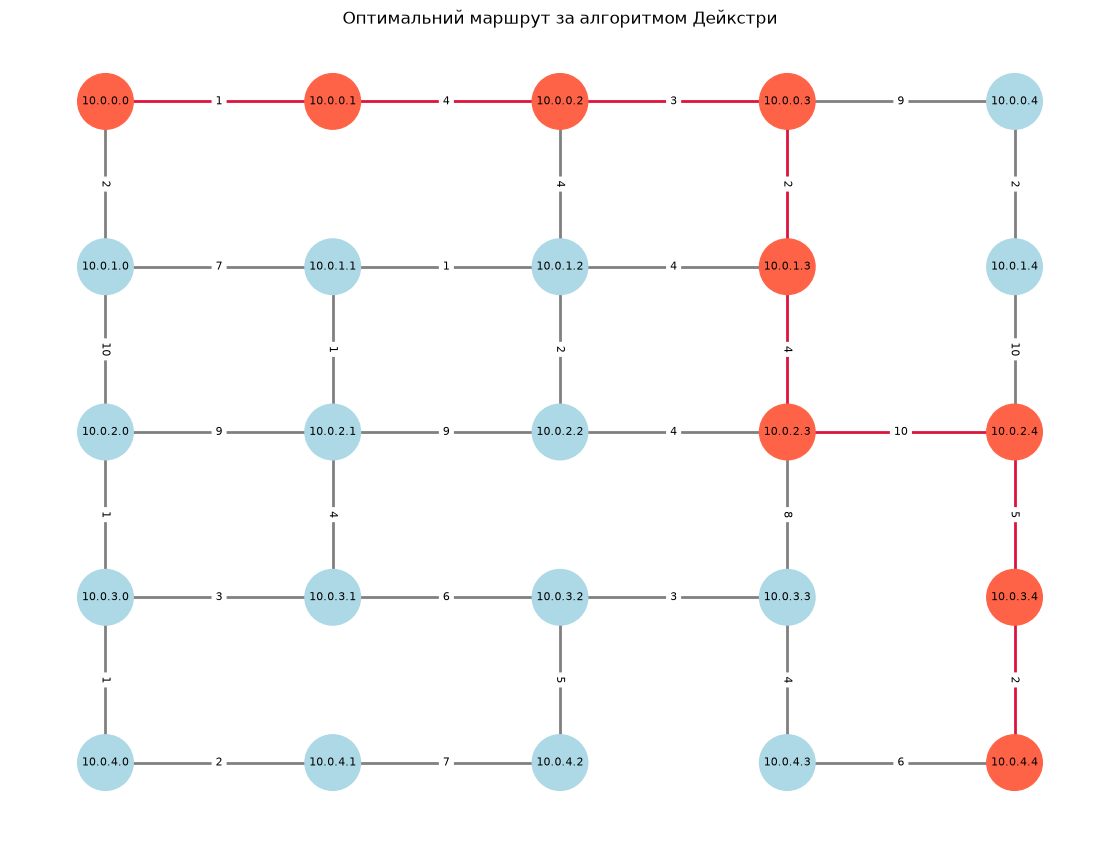

In [7]:
comparison = compare_paths(graph, start, target)

print('Шлях агента:     ', result.path)
print('Затримка агента: ', result.total_delay)
print('Шлях Дейкстри:   ', comparison['dijkstra_path'])
print('Затримка Дейкстри:', comparison['dijkstra_delay'])
draw_path(
    graph,
    comparison['dijkstra_path'],
    title='Оптимальний маршрут за алгоритмом Дейкстри'
)

## Порівняння на трьох топологіях

In [8]:
print(f"{'№':>3} {'Агент':>12} {'Дейкстра':>12} {'Вузли агента':>15} {'Повернення':>12}")
print('-' * 60)

for topology_number in range(1, 4):
    random.seed(100 + topology_number)
    test_graph = create_graph_for_lab2(
        nodes_num=25,
        edges_to_delete=6,
        min_weight=1,
        max_weight=10,
    )
    test_result = greedy_backtracking_agent(test_graph, start, target)
    test_comparison = compare_paths(test_graph, start, target)
    print(
        f'{topology_number:>3} '
        f'{test_result.total_delay:>12g} '
        f'{test_comparison["dijkstra_delay"]:>12g} '
        f'{len(test_result.path):>15} '
        f'{test_result.revoked_rules:>12}'
    )

  №        Агент     Дейкстра    Вузли агента   Повернення
------------------------------------------------------------
  1           90           40              21            1
  2           50           38              13            0
  3           76           35              19            3


## Висновок

Агент успішно будує маршрут, використовуючи лише інформацію про поточний вузол і його сусідів. Локальний вибір найменшої ваги не гарантує глобально оптимального маршруту, тому результат агента порівнюється з Дейкстрою, яка використовує повну топологію графа.